In [2]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import optuna

# =========================================================
# GLOBAL PRL SINGLE-COLUMN PUBLICATION STYLING
# =========================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'], 
    'font.size': 9, 
    'axes.labelsize': 9, 
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 300, 
    'savefig.dpi': 300, 
    'savefig.bbox': 'tight'
})

PAPER_COLORS = {
    'Neural Net': '#404040', 'Deep Neural Network': '#404040', 'CNN (Native)': '#404040',
    'XGBoost': '#B2182B', 'XGBoost (Raw)': '#B2182B',
    'LightGBM': '#D6604D', 'LightGBM (Raw)': '#D6604D',
    'CatBoost': '#F4A582', 'CatBoost (Raw)': '#F4A582',
    'XGBoost (CNN Feat)': '#2166AC', 'LightGBM (CNN Feat)': '#4393C3', 'CatBoost (CNN Feat)': '#92C5DE',
    'RandomForest': '#2166AC', 'GradientBoost': '#4393C3'
}

print("✅ Global setup complete. Strict Single-Column Styling loaded.")

✅ Global setup complete. Strict Single-Column Styling loaded.


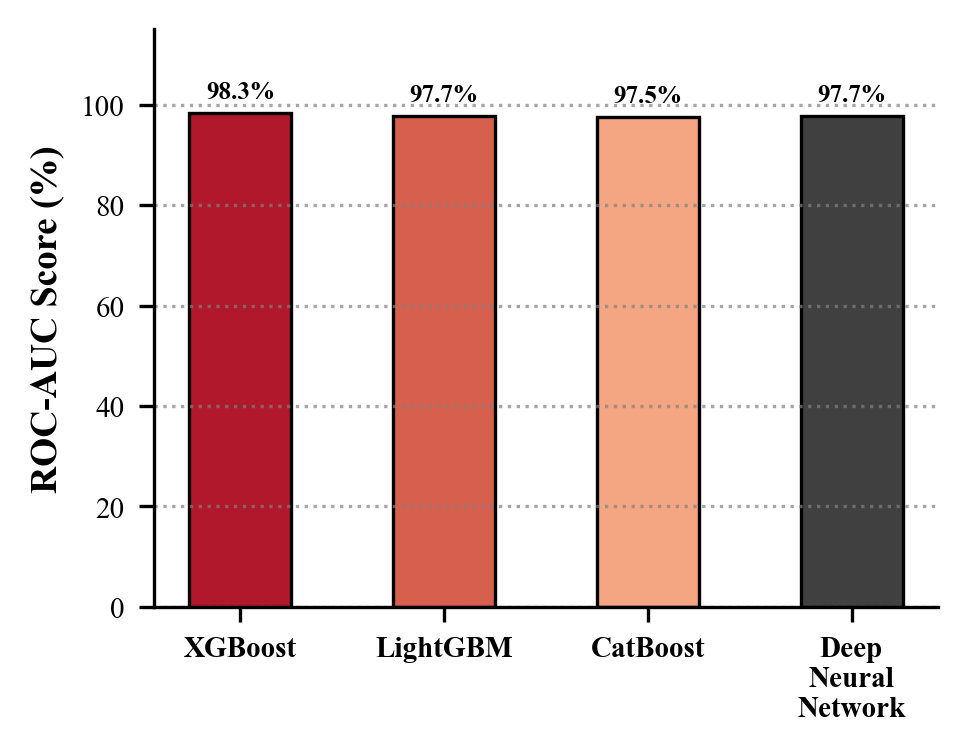

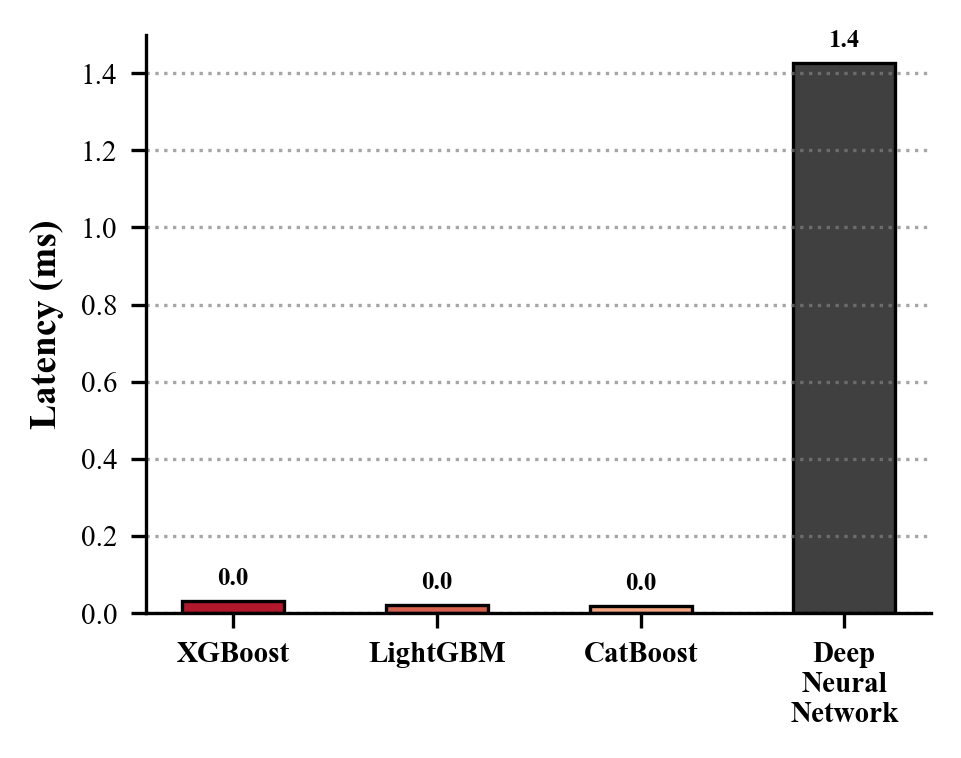

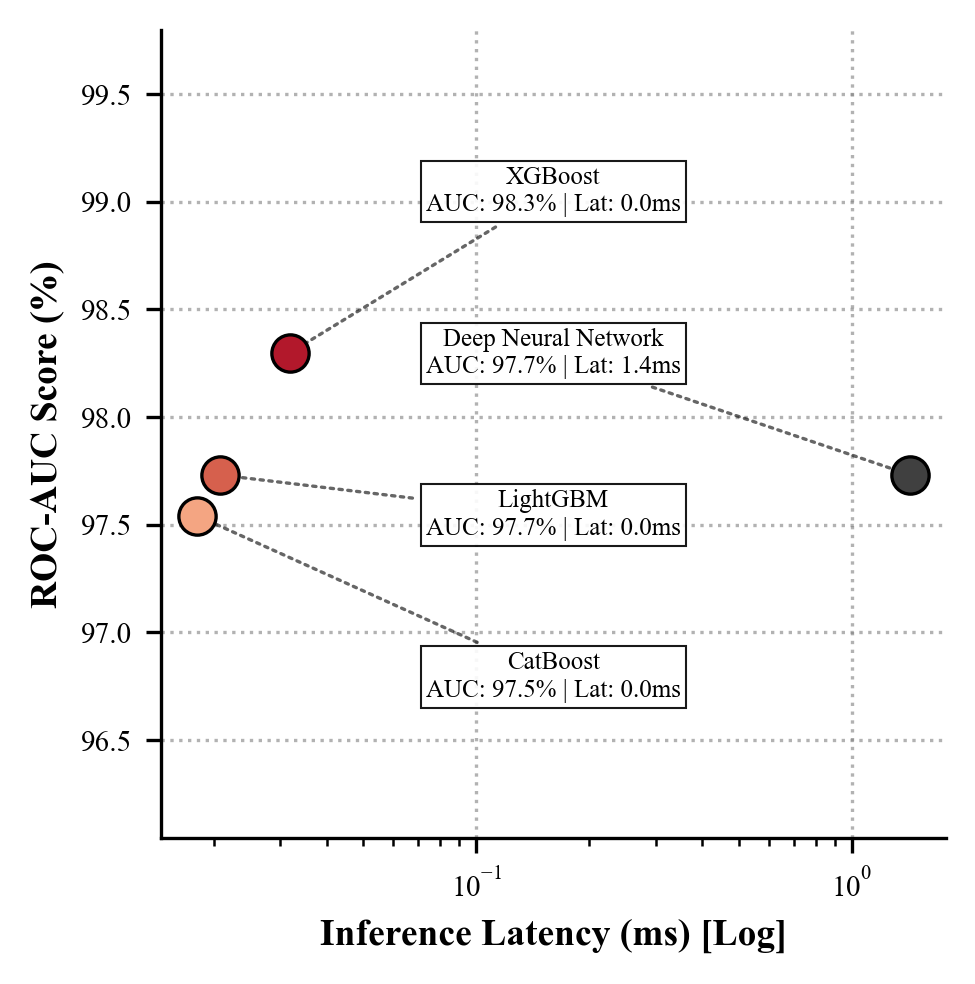

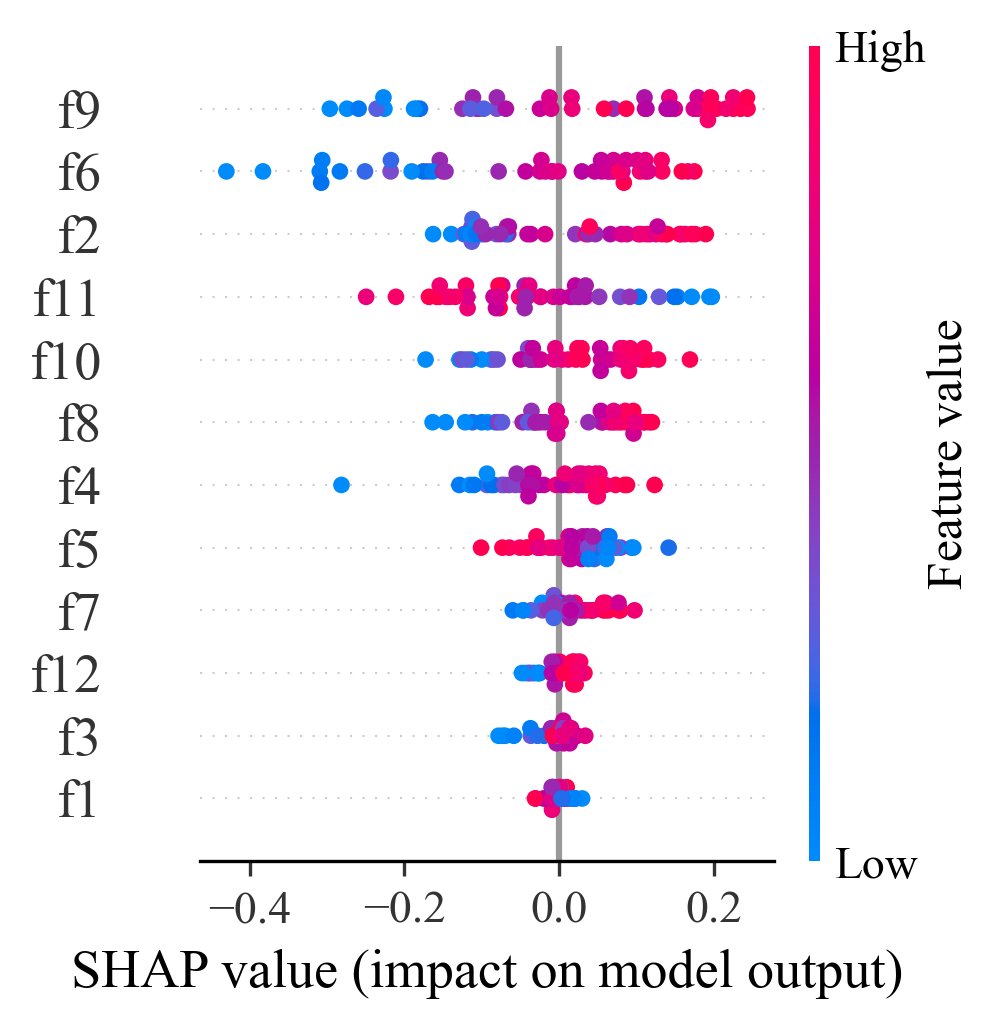

In [3]:
output_dir = 'plots/Tabular_Efficiency'
os.makedirs(output_dir, exist_ok=True)

try:
    with open("Data/tabular_plot_data.pkl", "rb") as f:
        tabular_data = pickle.load(f)
    eval_results, latencies = tabular_data["evaluation_results"], tabular_data["latency_results"]
    shap_vals_nn, x_test_scaled_tab, feature_names_tab = tabular_data["shap_values_nn"], tabular_data["x_test_scaled"], tabular_data["feature_names"]
except FileNotFoundError:
    pass

def plot_tabular_efficiency():
    models = list(eval_results.keys())
    x = np.arange(len(models))
    scores = [eval_results[m]['ROC-AUC'] * 100 for m in models]
    lats = [latencies[f'{m}_Latency_ms'] for m in models]
    
    # 1. Predictive Power
    fig1, ax1 = plt.subplots(figsize=(3.375, 2.5))
    bars1 = ax1.bar(x, scores, 0.5, color=[PAPER_COLORS.get(m, '#888888') for m in models], edgecolor='black', linewidth=0.8)
    ax1.set_ylabel('ROC-AUC Score (%)', weight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([m.replace(" ", "\n") for m in models], weight='bold', rotation=0)
    ax1.set_ylim(0, 115)
    ax1.grid(axis='y', linestyle=':', color='gray', alpha=0.7)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{bar.get_height():.1f}%', ha='center', va='bottom', weight='bold', fontsize=6)
    plt.savefig(f'{output_dir}/Tabular_Predictive_Power.pdf')
    plt.show() 

    # 2. Inference Latency
    fig2, ax2 = plt.subplots(figsize=(3.375, 2.5))
    bars2 = ax2.bar(x, lats, 0.5, color=[PAPER_COLORS.get(m, '#888888') for m in models], edgecolor='black', linewidth=0.8)
    ax2.set_ylabel('Latency (ms)', weight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([m.replace(" ", "\n") for m in models], weight='bold', rotation=0)
    ax2.grid(axis='y', linestyle=':', color='gray', alpha=0.7)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    for bar in bars2:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(lats)*0.02), f'{bar.get_height():.1f}', ha='center', va='bottom', weight='bold', fontsize=6)
    plt.savefig(f'{output_dir}/Tabular_Inference_Latency.pdf')
    plt.show()

    # 3. Pareto Frontier (Adapted for single column width)
    fig3, ax3 = plt.subplots(figsize=(3.375, 3.5))
    for i, m in enumerate(models):
        ax3.scatter(lats[i], scores[i], color=PAPER_COLORS.get(m, '#888888'), s=80, edgecolor='black', linewidth=0.8, zorder=3)

    ax3.set_xscale('log')
    y_min, y_max = min(scores) - 1.5, max(scores) + 1.5
    ax3.set_ylim(y_min, y_max)
    
    center_x = 10 ** ((np.log10(min(lats)) + np.log10(max(lats))) / 2)
    center_y_base = (y_min + y_max) / 2
    sorted_indices = np.argsort(scores)[::-1]
    y_step = (y_max - y_min) / 5 

    for rank, i in enumerate(sorted_indices):
        m = models[i]
        info_label = f"{m}\nAUC: {scores[i]:.1f}% | Lat: {lats[i]:.1f}ms"
        text_y = center_y_base + (len(models)/2 - rank - 0.5) * y_step
        ax3.annotate(info_label, xy=(lats[i], scores[i]), xytext=(center_x, text_y),          
            ha='center', va='center', fontsize=6, color='black',
            bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="black", lw=0.5, alpha=0.9),
            arrowprops=dict(arrowstyle="-", color='black', linestyle=':', lw=0.8, alpha=0.6), zorder=2)

    ax3.set_ylabel('ROC-AUC Score (%)', weight='bold')
    ax3.set_xlabel('Inference Latency (ms) [Log]', weight='bold')
    ax3.grid(True, linestyle=':', color='gray', alpha=0.6, zorder=0)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    plt.savefig(f'{output_dir}/Efficiency_Tradeoff_Professional.pdf')
    plt.show()

    # 4. Tabular NN SHAP 
    plt.figure(figsize=(3.375, 3.5))
    shap.summary_plot(shap_vals_nn, x_test_scaled_tab, feature_names=feature_names_tab, show=False, plot_size=None)
    plt.savefig(f'{output_dir}/SHAP_Neural_Network.pdf')
    plt.show()

if 'eval_results' in locals():
    plot_tabular_efficiency()

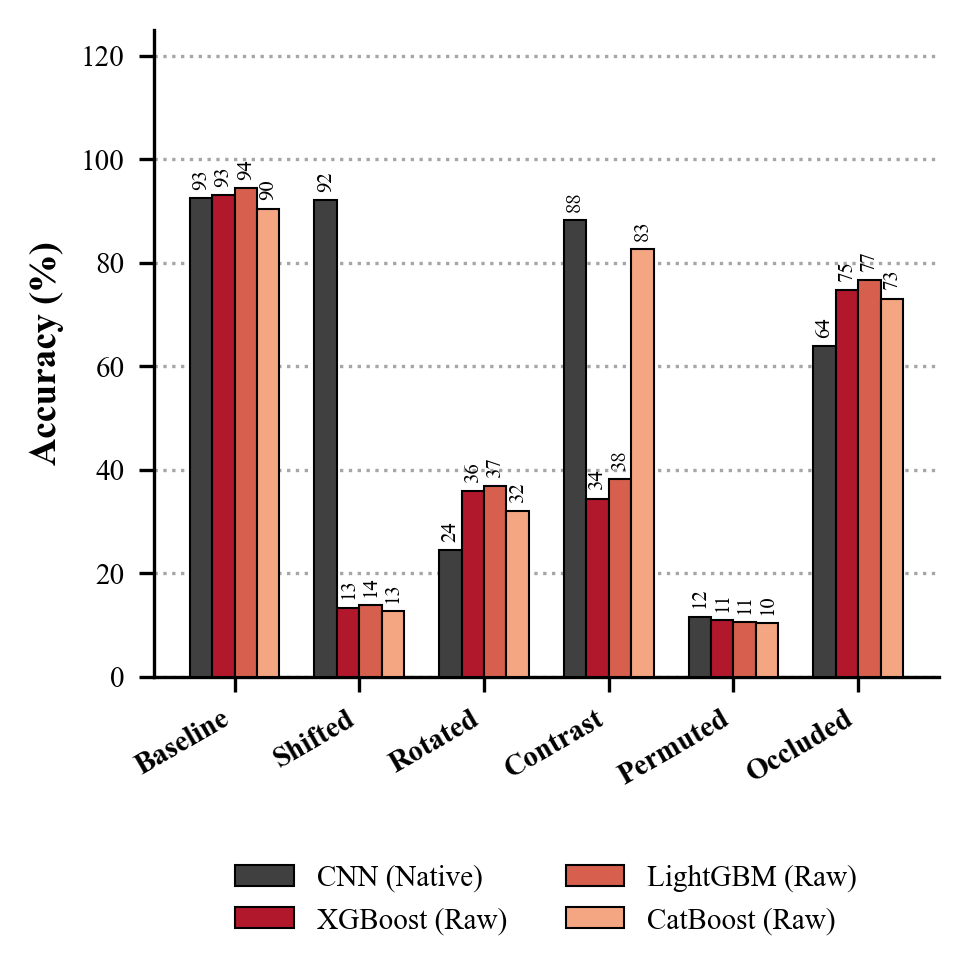

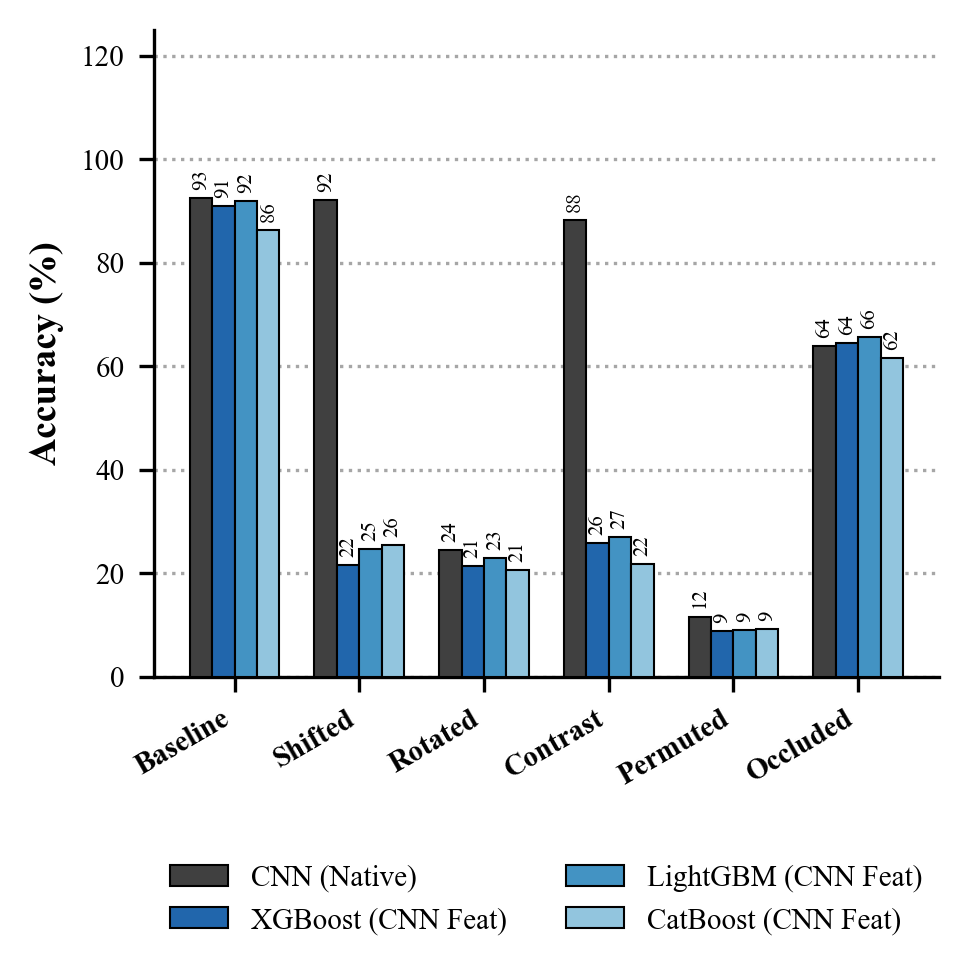

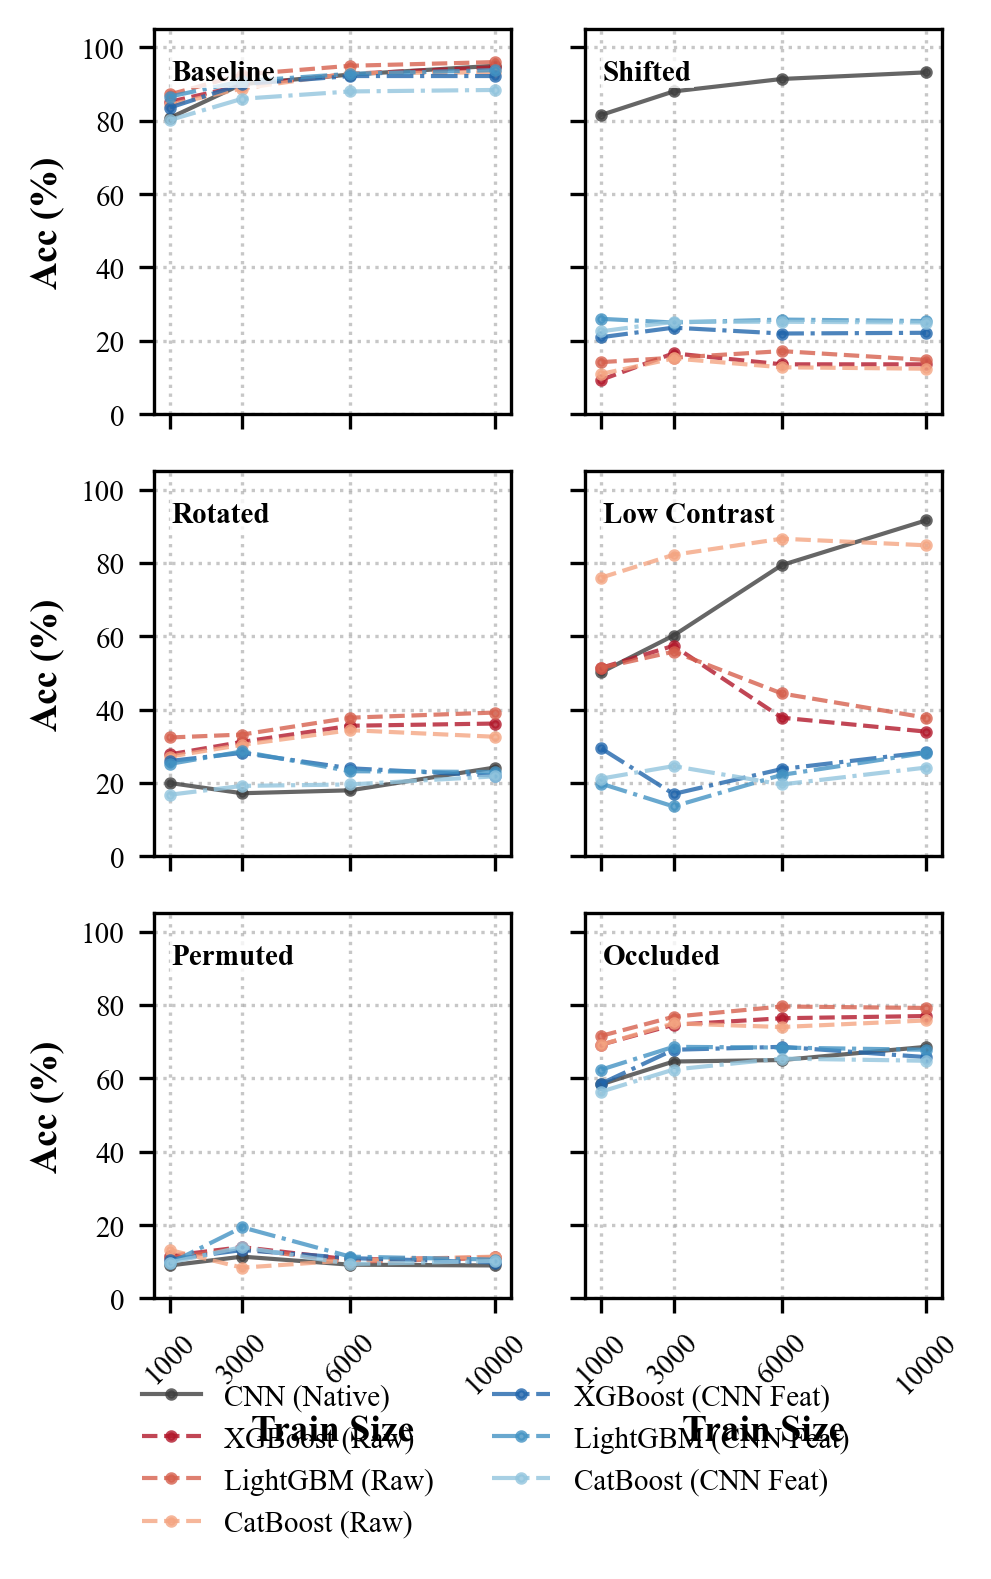

In [12]:
output_dir = 'plots/Spatial_Analysis'
os.makedirs(output_dir, exist_ok=True)

try:
    with open("Data/phase5_plot_data.pkl", "rb") as f:
        spatial_data = pickle.load(f)
    master_results, scaling_results = spatial_data["master_results"], spatial_data["scaling_results"]
    spatial_train_sizes, condition_names = spatial_data["train_sizes"], spatial_data["condition_names"]
except FileNotFoundError:
    pass

def plot_spatial_results():
    conditions = list(master_results[list(master_results.keys())[0]].keys())
    x = np.arange(len(conditions))
    width = 0.18 
    
    def add_labels(ax):
        for rect in ax.patches:
            height = rect.get_height()
            if height > 0:
                ax.annotate(f'{height:.0f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=5, color='black', rotation=90)

    # 1. Raw Tabular vs CNN 
    fig1, ax1 = plt.subplots(figsize=(3.375, 2.8))
    group1 = ['CNN (Native)', 'XGBoost (Raw)', 'LightGBM (Raw)', 'CatBoost (Raw)']
    for i, model in enumerate(group1):
        scores = [master_results[model][cond] * 100 for cond in conditions]
        ax1.bar(x + (i - len(group1)/2 + 0.5) * width, scores, width, label=model, color=PAPER_COLORS[model], edgecolor='black', linewidth=0.5, zorder=3)
        
    ax1.set_ylabel('Accuracy (%)', weight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(conditions, weight='bold', rotation=30, ha='right')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylim(0, 125) 
    ax1.grid(axis='y', linestyle=':', color='gray', alpha=0.7, zorder=0)
    add_labels(ax1)
    ax1.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2)
    plt.savefig(f'{output_dir}/Spatial_Plot_A_Raw.pdf')
    plt.show() 

    # 2. Hybrid GBDTs vs CNN 
    fig2, ax2 = plt.subplots(figsize=(3.375, 2.8))
    group2 = ['CNN (Native)', 'XGBoost (CNN Feat)', 'LightGBM (CNN Feat)', 'CatBoost (CNN Feat)']
    for i, model in enumerate(group2):
        scores = [master_results[model][cond] * 100 for cond in conditions]
        ax2.bar(x + (i - len(group2)/2 + 0.5) * width, scores, width, label=model, color=PAPER_COLORS[model], edgecolor='black', linewidth=0.5, zorder=3)
        
    ax2.set_ylabel('Accuracy (%)', weight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(conditions, weight='bold', rotation=30, ha='right')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_ylim(0, 125)
    ax2.grid(axis='y', linestyle=':', color='gray', alpha=0.7, zorder=0)
    add_labels(ax2)
    ax2.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2)
    plt.savefig(f'{output_dir}/Spatial_Plot_B_Hybrid.pdf')
    plt.show()

    # 3. Scaling Learning Curves (Converted to 3x2 Grid for single column)
    ls_map = {'CNN (Native)': '-', 'XGBoost (Raw)': '--', 'LightGBM (Raw)': '--', 'CatBoost (Raw)': '--',
              'XGBoost (CNN Feat)': '-.', 'LightGBM (CNN Feat)': '-.', 'CatBoost (CNN Feat)': '-.'}

    fig, axes = plt.subplots(3, 2, figsize=(3.375, 5.0), sharex=True, sharey=True)
    for i, cond in enumerate(condition_names):
        ax = axes.flatten()[i]
        for model_name, model_results in scaling_results.items():
            ax.plot(spatial_train_sizes, [val * 100 for val in model_results[cond]], label=model_name, 
                    color=PAPER_COLORS[model_name], linestyle=ls_map[model_name], marker='o', markersize=2, linewidth=1.0, alpha=0.8)
            
        ax.text(0.05, 0.92, cond, transform=ax.transAxes, weight='bold', fontsize=7, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.5))
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.set_ylim(0, 105)
        if i % 2 == 0: ax.set_ylabel('Acc (%)', weight='bold')
        if i >= 4: ax.set_xlabel('Train Size', weight='bold')
        if i >= 4: ax.set_xticks(spatial_train_sizes)
        ax.tick_params(axis='x', rotation=45)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/Spatial_Phase_Learning_Curves.pdf')
    plt.show()

if 'master_results' in locals():
    plot_spatial_results()

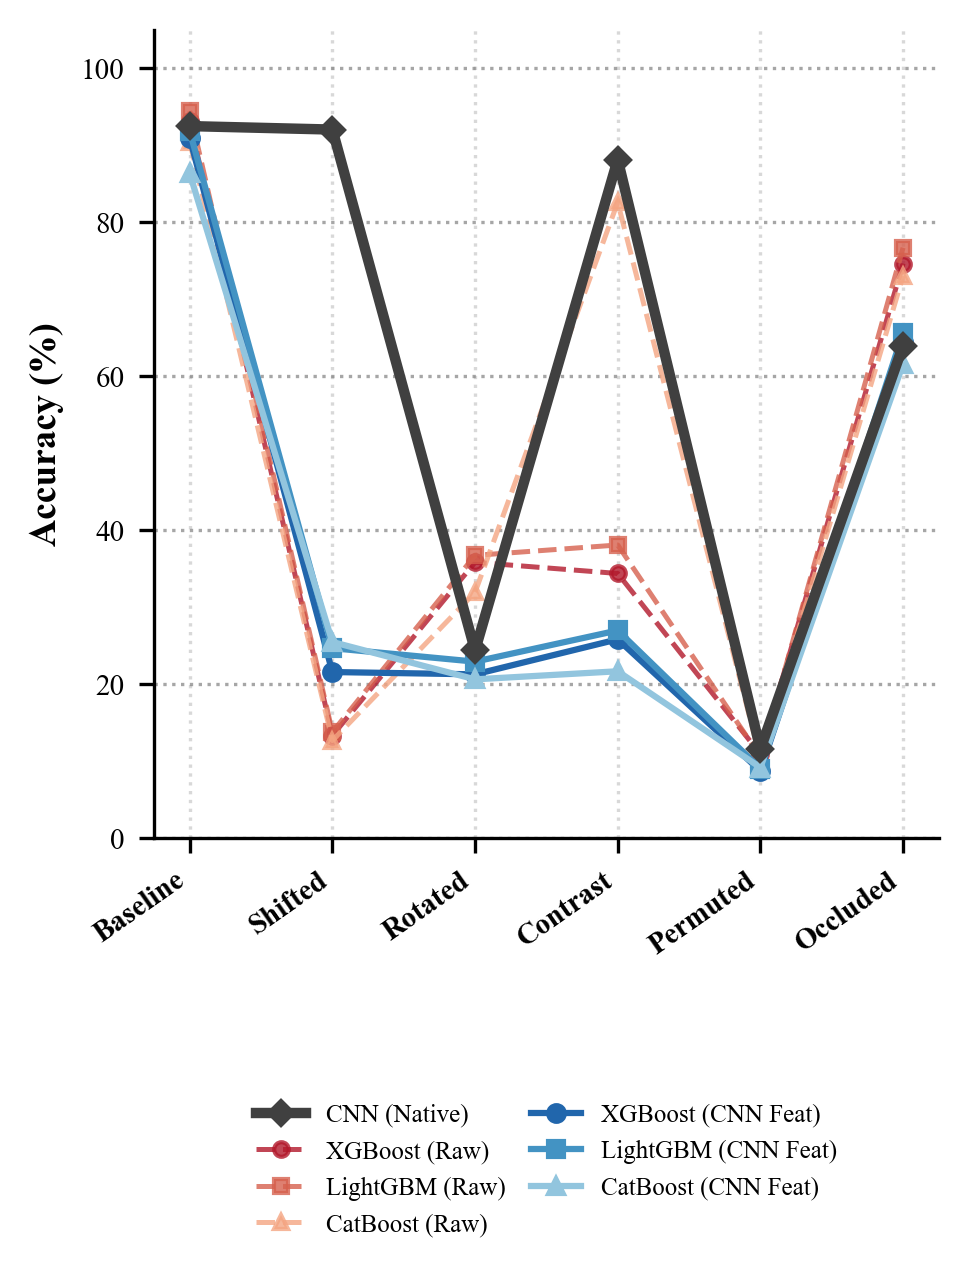

In [14]:
# =========================================================
    # COMBINED SPATIAL ROBUSTNESS (Profile Line Plot)
    # =========================================================
def plot_spatial_results():
    conditions = list(master_results[list(master_results.keys())[0]].keys())
    
    # We use a slightly taller figure to accommodate the legend at the bottom
    fig, ax = plt.subplots(figsize=(3.375, 3.5))
    
    # Define groups for styling
    cnn_model = 'CNN (Native)'
    models_raw = ['XGBoost (Raw)', 'LightGBM (Raw)', 'CatBoost (Raw)']
    models_hybrid = ['XGBoost (CNN Feat)', 'LightGBM (CNN Feat)', 'CatBoost (CNN Feat)']
    
    # Base markers for the 3 GBDT frameworks
    markers = ['o', 's', '^'] 
    
    # 1. Plot Native CNN (Thick baseline)
    cnn_scores = [master_results[cnn_model][cond] * 100 for cond in conditions]
    ax.plot(conditions, cnn_scores, label=cnn_model, color=PAPER_COLORS[cnn_model], 
            linewidth=2.5, marker='D', markersize=4, zorder=5)

    # 2. Plot Raw GBDTs (Dashed lines, lighter alpha)
    for i, model in enumerate(models_raw):
        scores = [master_results[model][cond] * 100 for cond in conditions]
        ax.plot(conditions, scores, label=model, color=PAPER_COLORS[model], 
                linewidth=1.2, linestyle='--', marker=markers[i], markersize=3.5, alpha=0.8, zorder=3)

    # 3. Plot Hybrid GBDTs (Solid lines)
    for i, model in enumerate(models_hybrid):
        scores = [master_results[model][cond] * 100 for cond in conditions]
        ax.plot(conditions, scores, label=model, color=PAPER_COLORS[model], 
                linewidth=1.5, linestyle='-', marker=markers[i], markersize=4, zorder=4)

    # --- Formatting for PRL Single Column ---
    ax.set_ylabel('Accuracy (%)', weight='bold')
    ax.set_ylim(0, 105) # Cap at 105 to give a tiny bit of headroom
    
    # Angle the x-labels so they don't overlap
    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(conditions, weight='bold', rotation=35, ha='right', fontsize=7)
    
    # Clean grid and borders
    ax.grid(axis='y', linestyle=':', color='gray', alpha=0.7)
    ax.grid(axis='x', linestyle=':', color='gray', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Custom Legend: Pushed outside the plot, organized in 2 columns
    ax.legend(bbox_to_anchor=(0.5, -0.3), loc='upper center', ncol=2, 
              frameon=False, fontsize=6, columnspacing=1.0)
    
    plt.savefig(f'{output_dir}/Spatial_Combined_Profile.pdf', bbox_inches='tight')
    plt.show()
plot_spatial_results()

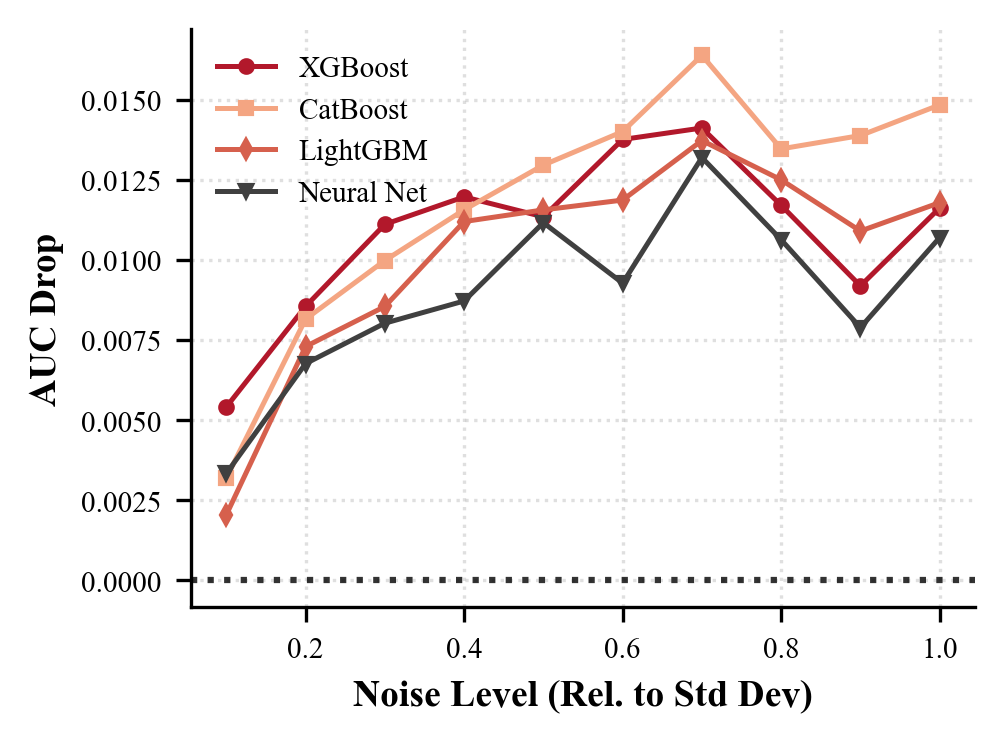

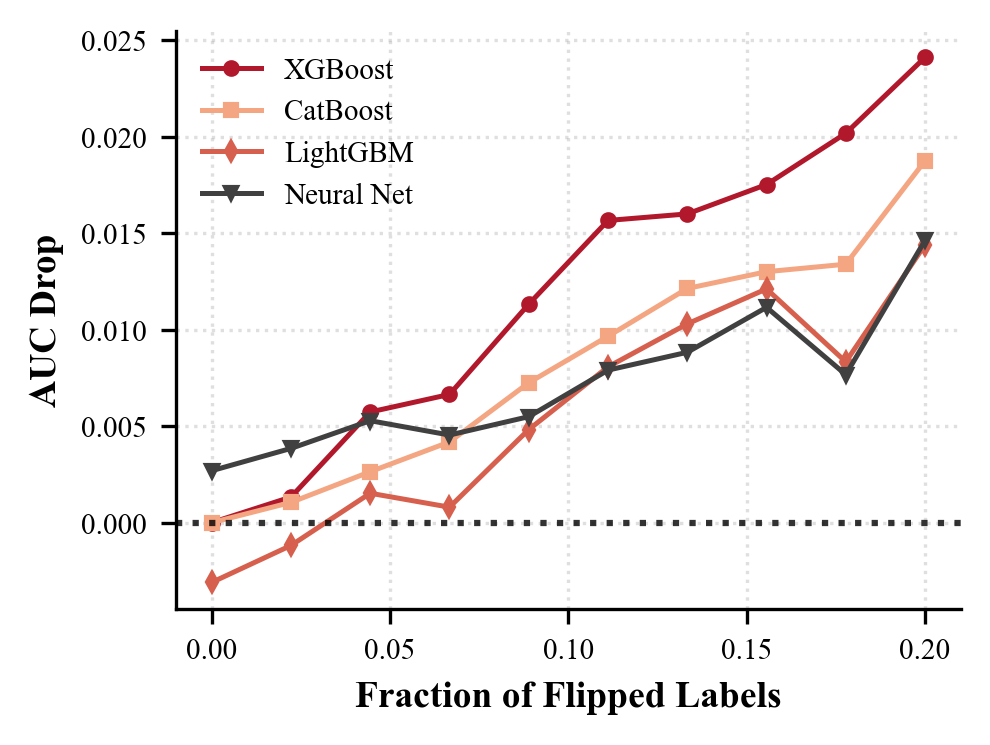

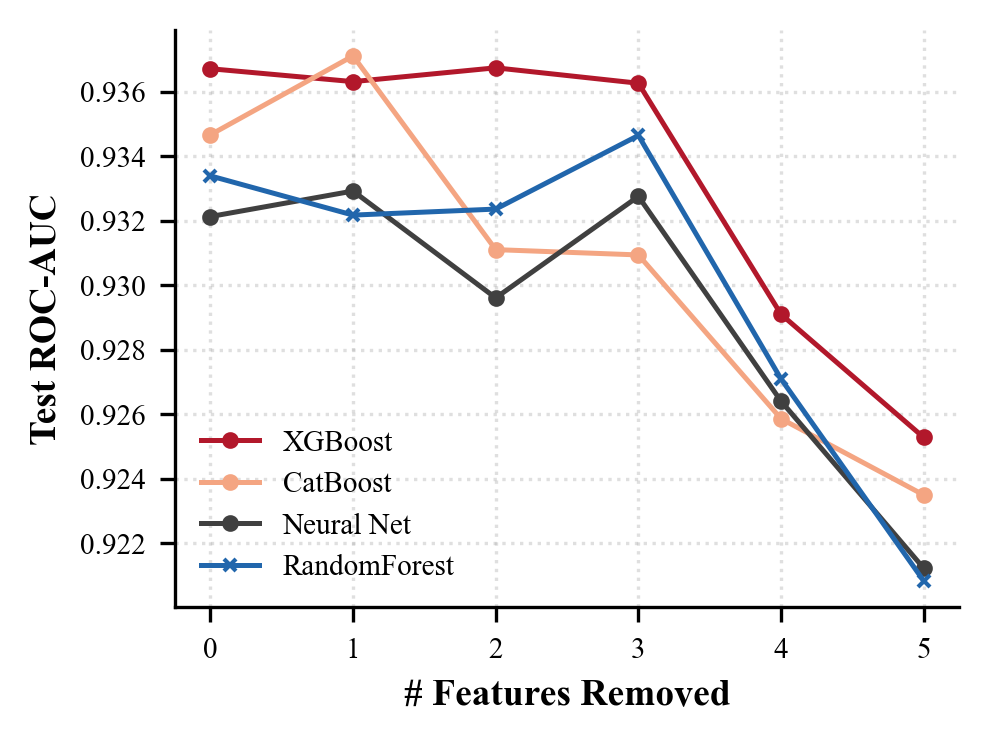

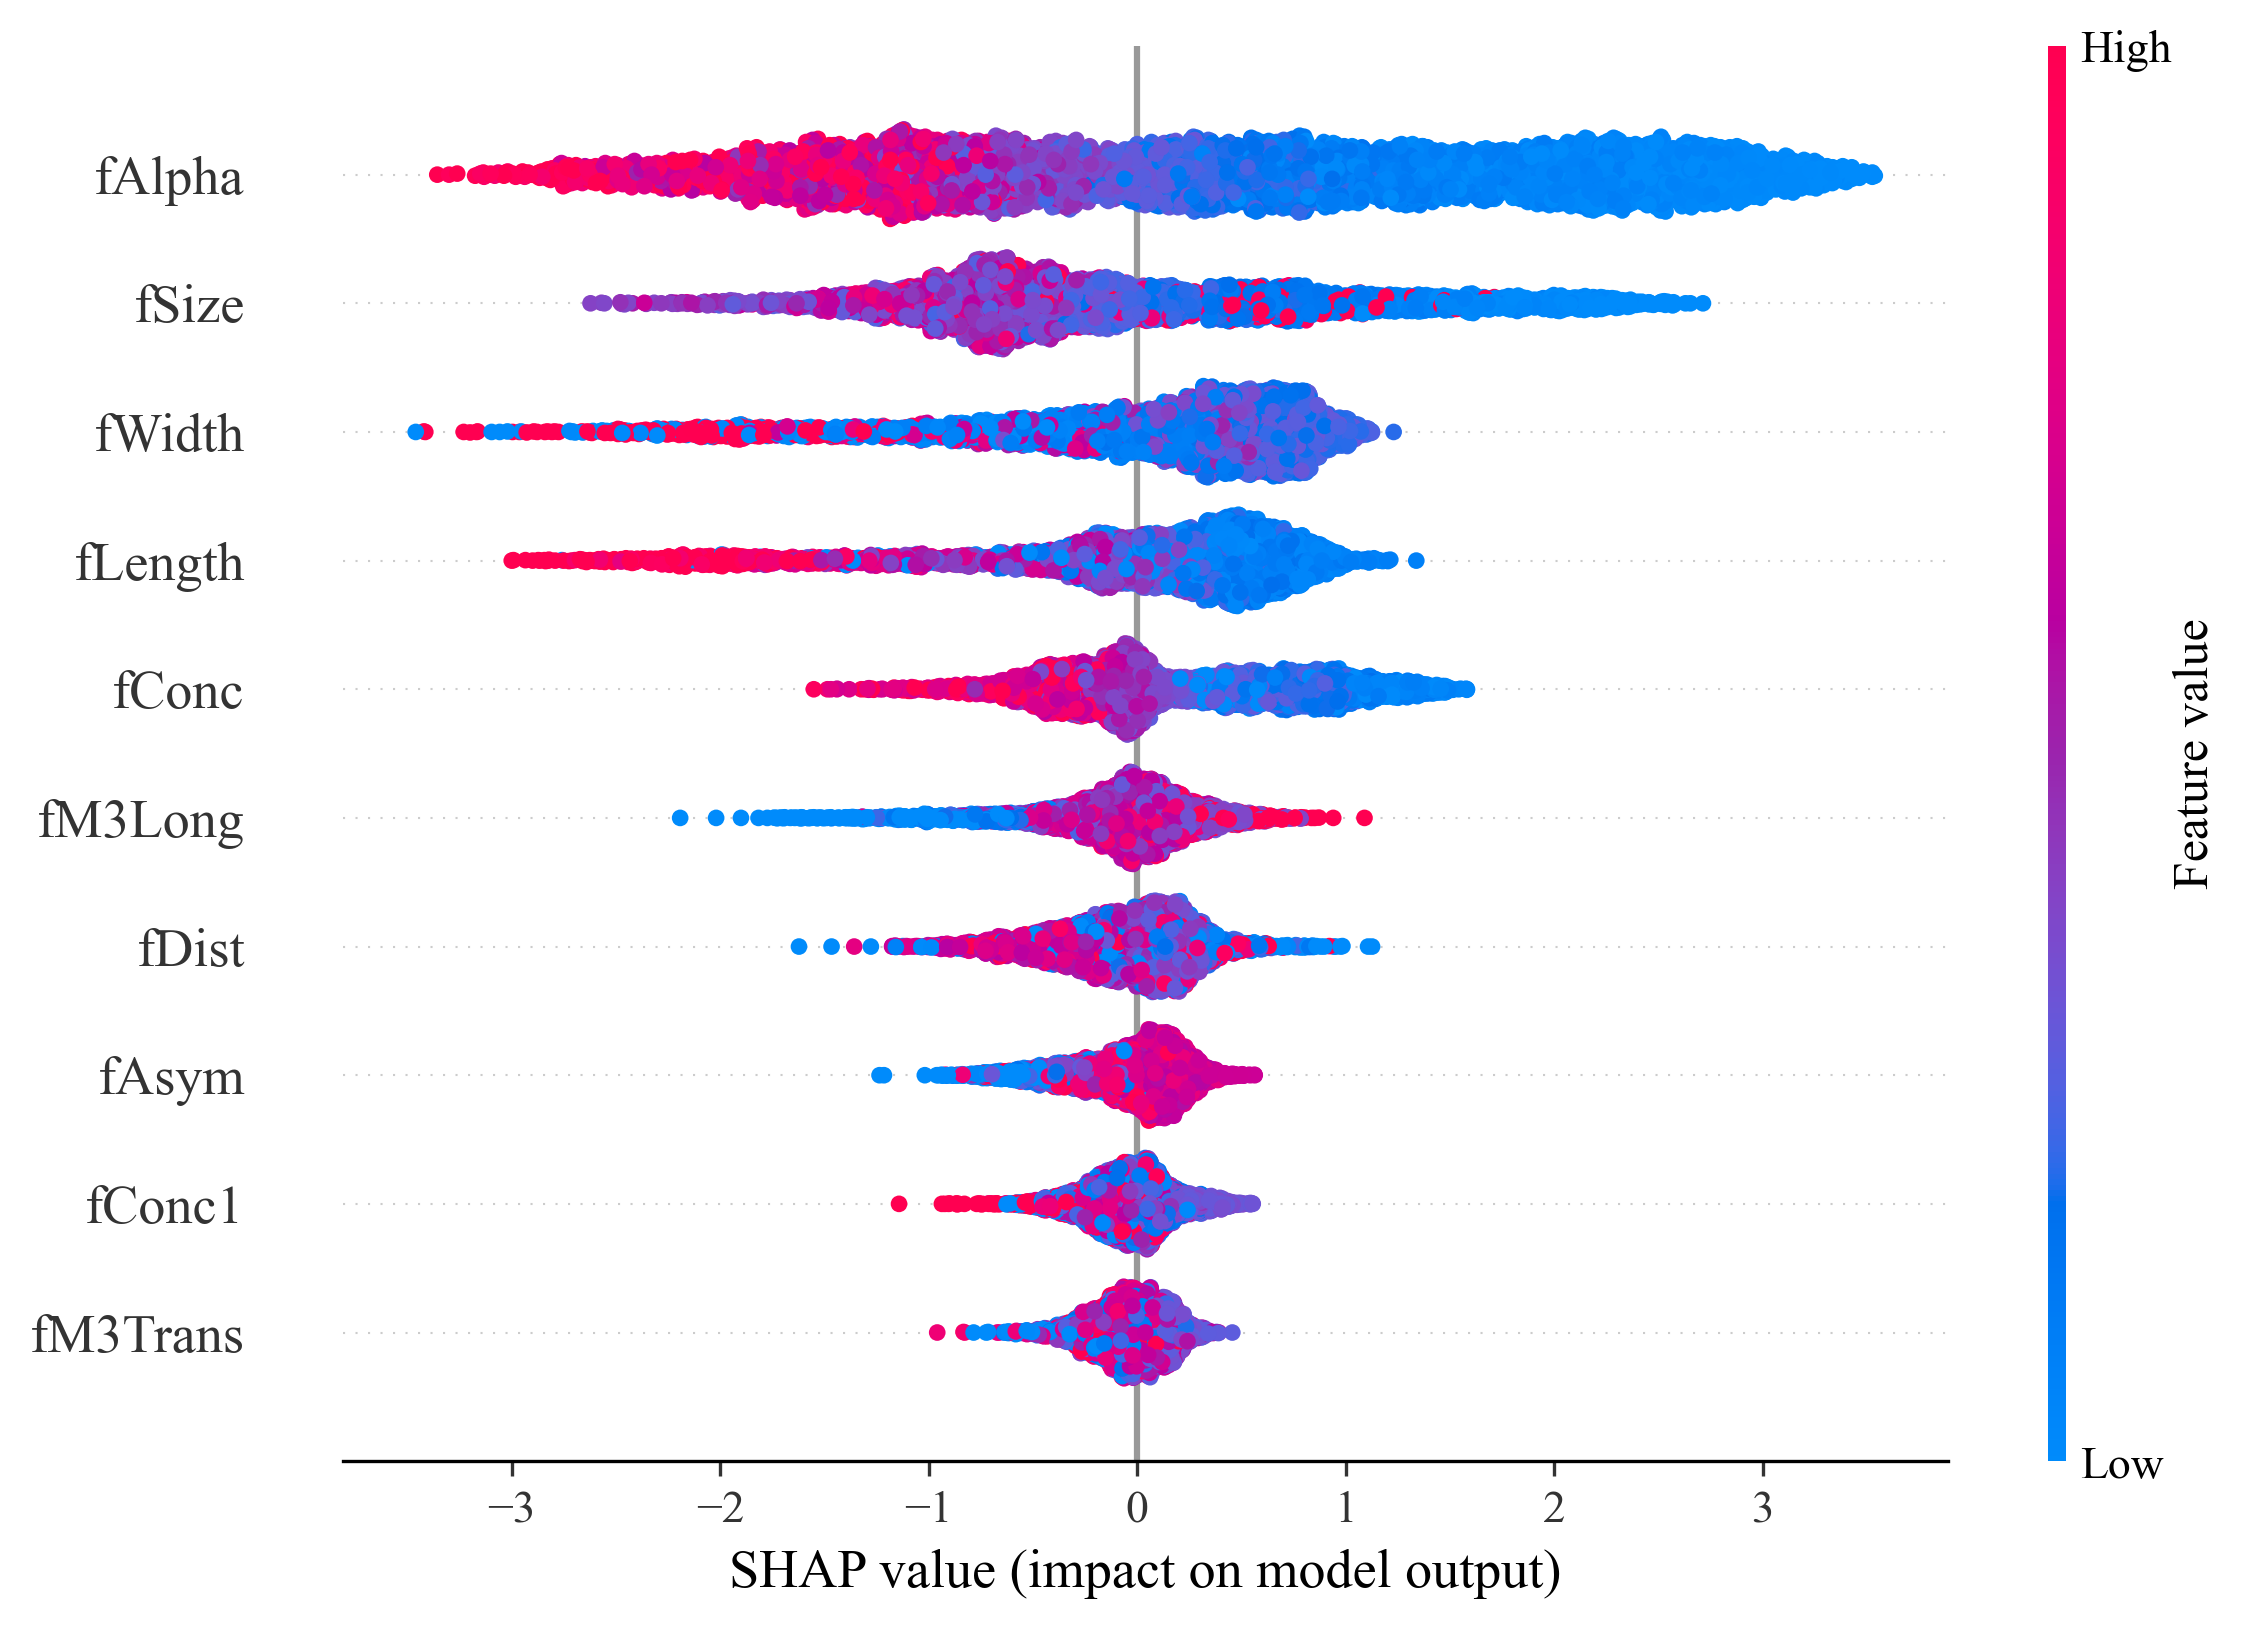

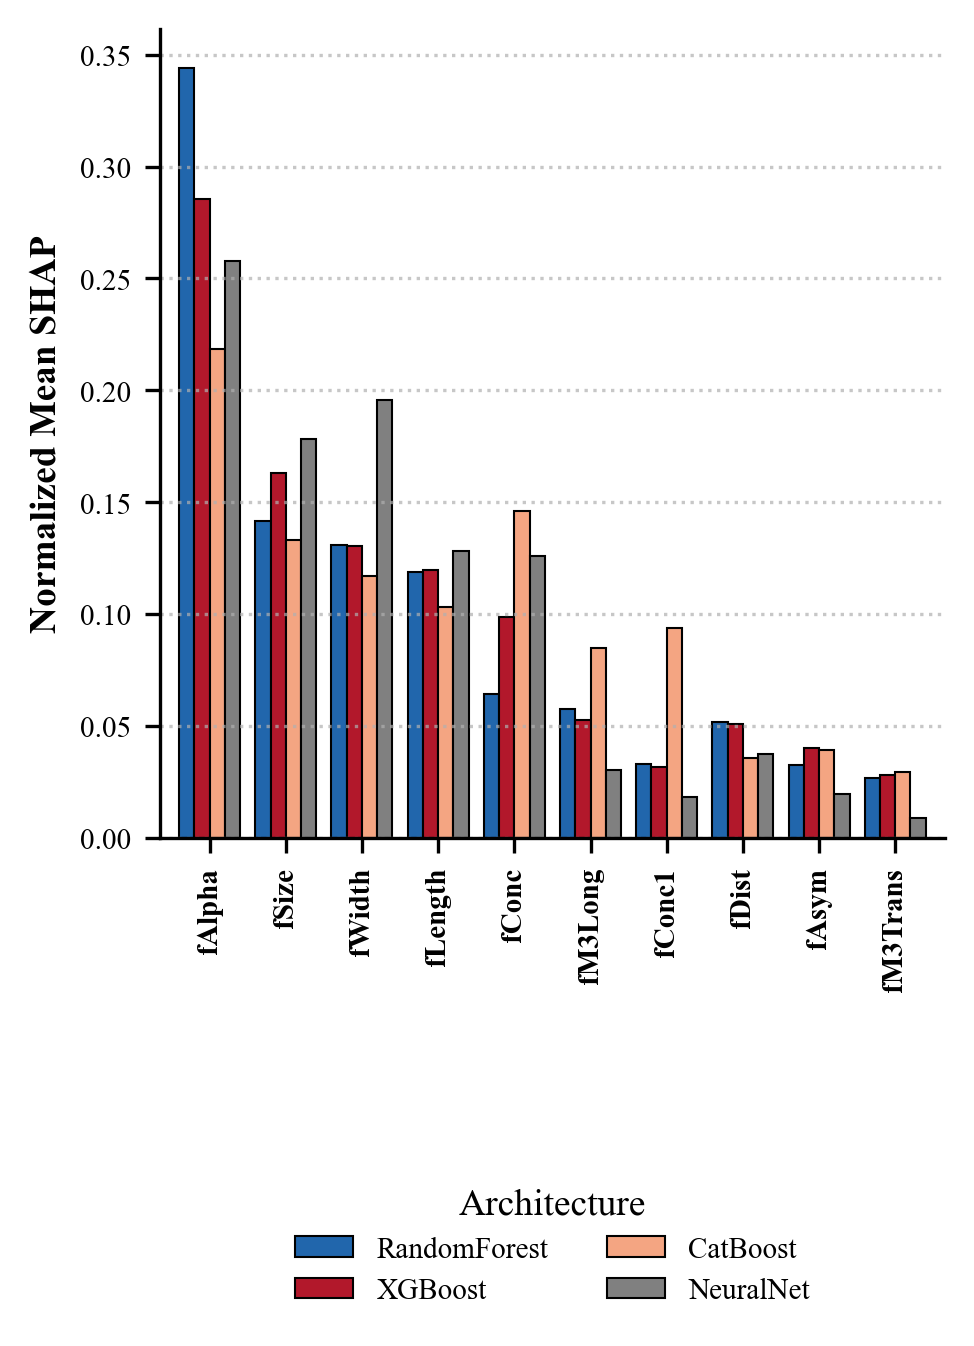

In [9]:
output_dir = 'plots/Phase2_Degradation'
os.makedirs(output_dir, exist_ok=True)

try:
    x_test_magic, _ = joblib.load('Data/test_data.pkl') 
    shap_data, norm_shap_df = joblib.load('Data/shap_feature_importance.pkl'), joblib.load('Data/shap_importance_norm.pkl')
    f_noise, l_noise = joblib.load('Data/feature_noise_results.pkl'), joblib.load('Data/label_noise_results.pkl')
    
    try:
        fe_data = joblib.load('Data/feature_elimination_results.pkl')
        n_dropped_list, results_fe = fe_data['n_dropped_list'], fe_data['results_fe']
    except FileNotFoundError:
        n_dropped_list, results_fe = None, None
except FileNotFoundError:
    pass

def plot_phase_2():
    # 1. Feature Noise Degradation 
    fig1, ax1 = plt.subplots(figsize=(3.375, 2.5))
    ax1.plot(f_noise['noise_levels'], f_noise['auc_drop_xgb'], 'o-', label='XGBoost', color=PAPER_COLORS['XGBoost'], lw=1.2, markersize=3)
    ax1.plot(f_noise['noise_levels'], f_noise['auc_drop_cb'], 's-', label='CatBoost', color=PAPER_COLORS['CatBoost'], lw=1.2, markersize=3)
    ax1.plot(f_noise['noise_levels'], f_noise['auc_drop_lgb'], 'd-', label='LightGBM', color=PAPER_COLORS['LightGBM'], lw=1.2, markersize=3)
    ax1.plot(f_noise['noise_levels'], f_noise['auc_drop_nn'], 'v-', label='Neural Net', color=PAPER_COLORS['Neural Net'], lw=1.2, markersize=3)
    
    ax1.axhline(y=0, color='black', linestyle=':', alpha=0.8)
    ax1.set_xlabel('Noise Level (Rel. to Std Dev)', weight='bold')
    ax1.set_ylabel('AUC Drop', weight='bold')
    ax1.legend(frameon=False, loc='upper left')
    ax1.grid(True, linestyle=':', alpha=0.4)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    plt.savefig(f'{output_dir}/Phase2_Feature_Noise.pdf')
    plt.show()

    # 2. Label Noise Degradation 
    fig2, ax2 = plt.subplots(figsize=(3.375, 2.5))
    ax2.plot(l_noise['noise_levels'], l_noise['auc_drop_xgb'], 'o-', label='XGBoost', color=PAPER_COLORS['XGBoost'], lw=1.2, markersize=3)
    ax2.plot(l_noise['noise_levels'], l_noise['auc_drop_cb'], 's-', label='CatBoost', color=PAPER_COLORS['CatBoost'], lw=1.2, markersize=3)
    ax2.plot(l_noise['noise_levels'], l_noise['auc_drop_lgb'], 'd-', label='LightGBM', color=PAPER_COLORS['LightGBM'], lw=1.2, markersize=3)
    ax2.plot(l_noise['noise_levels'], l_noise['auc_drop_nn'], 'v-', label='Neural Net', color=PAPER_COLORS['Neural Net'], lw=1.2, markersize=3)
    
    ax2.axhline(y=0, color='black', linestyle=':', alpha=0.8)
    ax2.set_xlabel('Fraction of Flipped Labels', weight='bold')
    ax2.set_ylabel('AUC Drop', weight='bold')
    ax2.legend(frameon=False, loc='upper left')
    ax2.grid(True, linestyle=':', alpha=0.4)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    plt.savefig(f'{output_dir}/Phase2_Label_Noise.pdf')
    plt.show()

    # 3. Feature Elimination 
    if results_fe is not None:
        fig3, ax3 = plt.subplots(figsize=(3.375, 2.5))
        mapping = {'XGBoost': 'XGBoost', 'CatBoost': 'CatBoost', 'NeuralNet': 'Neural Net', 'RandomForest': 'RandomForest'} 
        for orig_key, new_key in mapping.items():
            if orig_key in results_fe:
                marker = 'x-' if new_key == 'RandomForest' else 'o-'
                ax3.plot(n_dropped_list, results_fe[orig_key], marker, label=new_key, color=PAPER_COLORS[new_key], lw=1.2, markersize=3)
                
        ax3.set_xlabel('# Features Removed', weight='bold')
        ax3.set_ylabel('Test ROC-AUC', weight='bold')
        ax3.set_xticks(n_dropped_list)
        ax3.legend(frameon=False, loc='lower left')
        ax3.grid(True, linestyle=':', alpha=0.4)
        ax3.spines['top'].set_visible(False)
        ax3.spines['right'].set_visible(False)
        plt.savefig(f'{output_dir}/Phase2_Feature_Elimination.pdf')
        plt.show()

    # 4. XGBoost SHAP Summary
    plt.figure(figsize=(3.375, 3.5))
    shap.summary_plot(shap_data['shap_values_xgb'], x_test_magic, feature_names=shap_data['feature_names'], show=False)
    plt.savefig(f'{output_dir}/Phase2_SHAP_XGBoost.pdf')
    plt.show()

    # 5. Normalized SHAP (Adapted for Single Column)
    row_means = norm_shap_df.mean(axis=1)
    shap_sorted = norm_shap_df.loc[row_means.sort_values().index][::-1]

    fig4, ax4 = plt.subplots(figsize=(3.375, 3.5))
    plot_colors = [PAPER_COLORS.get(c, 'gray') for c in shap_sorted.columns]
    
    shap_sorted.plot(kind='bar', ax=ax4, width=0.8, color=plot_colors, edgecolor='black', linewidth=0.5)
    ax4.set_ylabel('Normalized Mean SHAP', weight='bold')
    ax4.set_xticklabels(shap_sorted.index, rotation=90, ha='center', weight='bold')
    
    # Legend pushed down to avoid overlapping the bars
    ax4.legend(title='Architecture', bbox_to_anchor=(0.5, -0.4), loc='upper center', ncol=2, frameon=False)
    ax4.grid(axis='y', linestyle=':', alpha=0.7)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    plt.savefig(f'{output_dir}/Phase2_Normalized_SHAP.pdf')
    plt.show()

if 'shap_data' in locals():
    plot_phase_2()

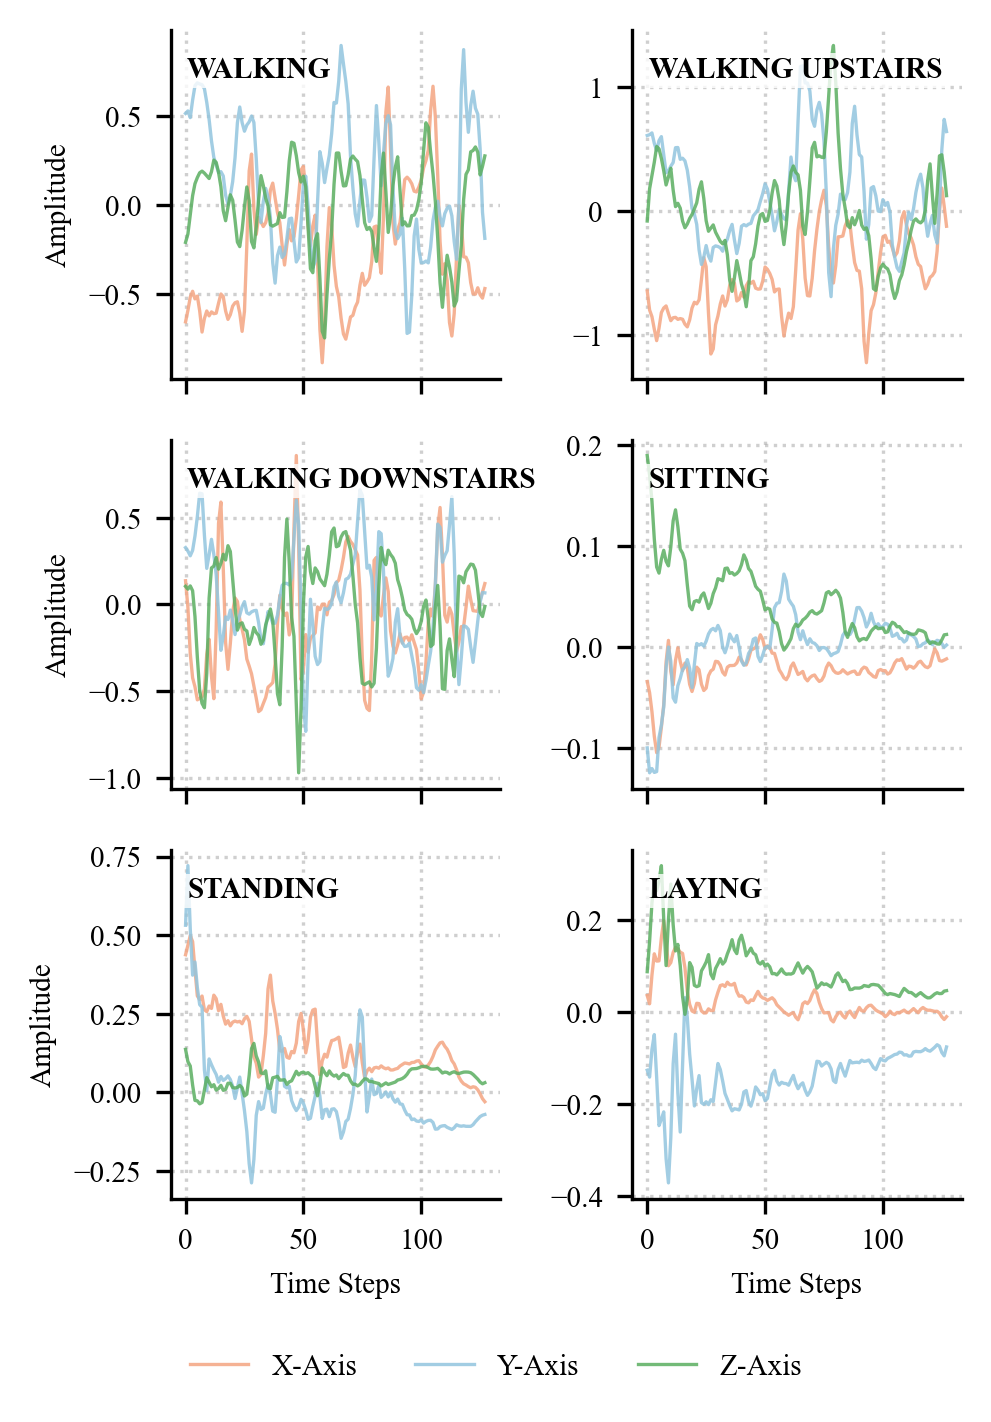

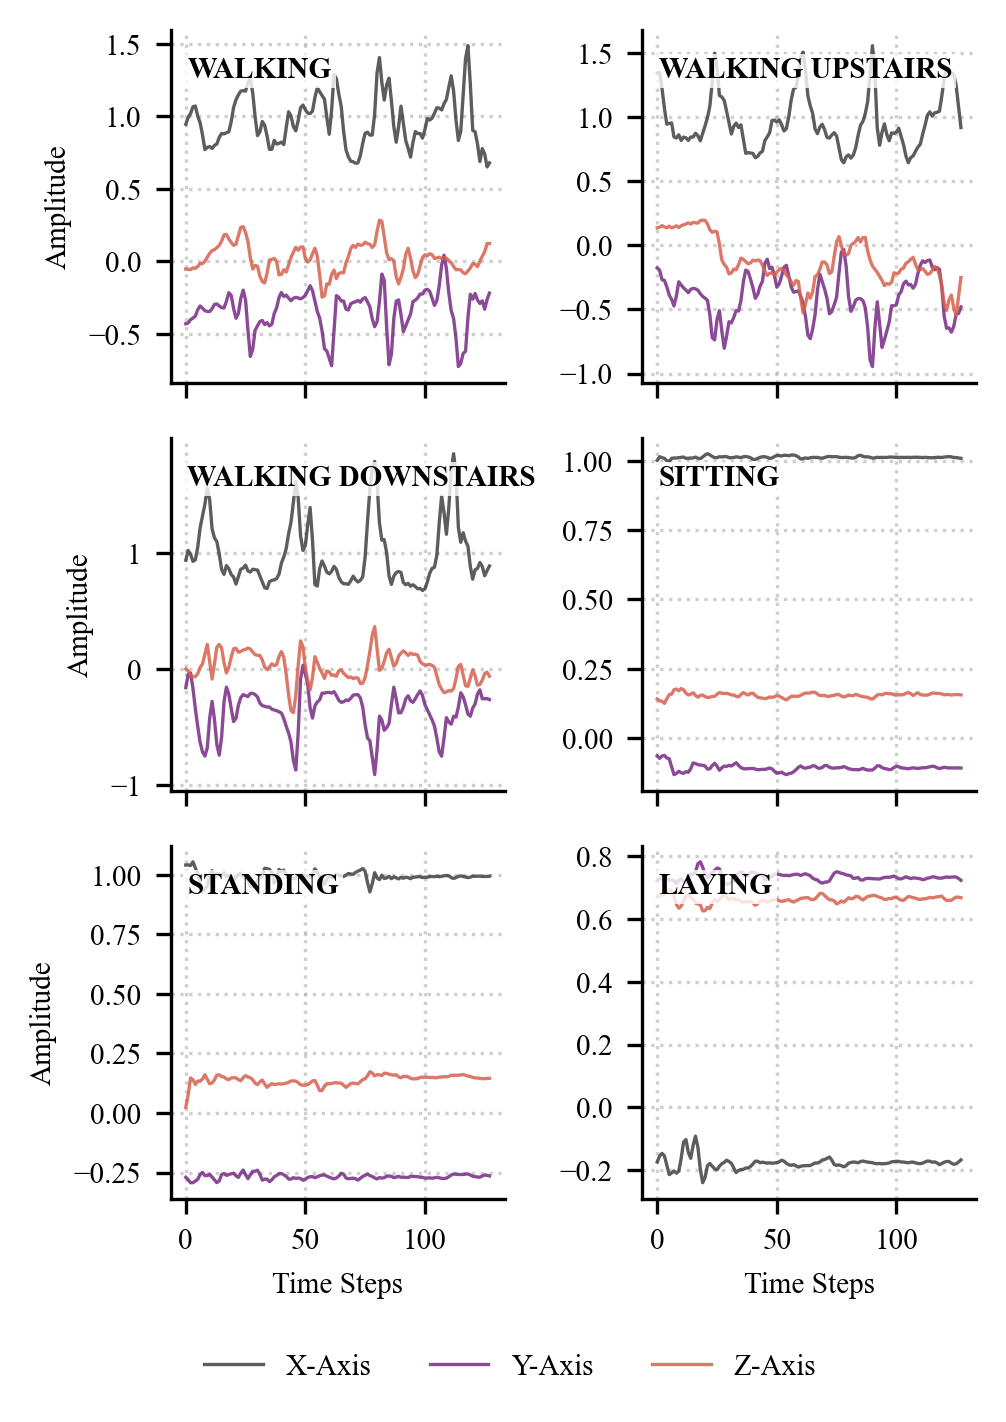

/var/folders/fx/lyshfmvn7wd2c3vfvlc6g16w0000gn/T/ipykernel_29146/615578343.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), weight='bold', fontsize=6)


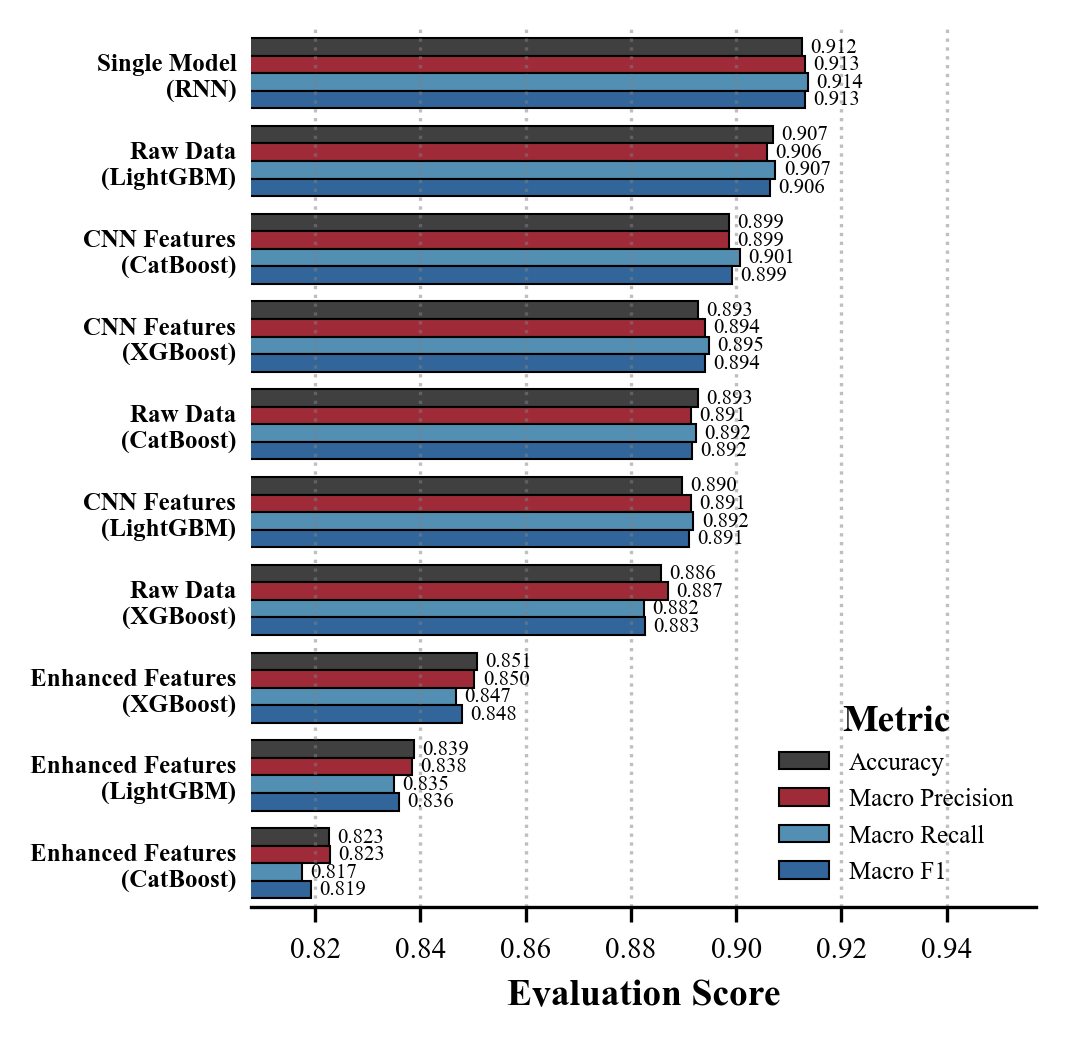

In [7]:
output_dir_ts = 'plots/TimeSeries_Analysis'
output_dir_mc = 'plots/Multiclassification_Analysis'
os.makedirs(output_dir_ts, exist_ok=True)
os.makedirs(output_dir_mc, exist_ok=True)

try:
    with open("Data/time_series_plot_data.pkl", "rb") as f:
        ts_data = pickle.load(f)
    X_ts, y_cat, activity_labels = ts_data["X_test_raw"], ts_data["y_test_cat"], ts_data["activity_labels"]
except FileNotFoundError:
    pass

try:
    with open("Data/multiclass_plot_data.pkl", "rb") as f:
        mc_data = pickle.load(f)
    performance_registry = mc_data["performance_registry"]
except FileNotFoundError:
    performance_registry = []

def plot_time_series_sensor_grid(X, y_cat, labels, mode='total'):
    y_int = np.argmax(y_cat, axis=1)
    unique_activities = np.unique(y_int)

    if mode == 'body':
        start_idx, colors = 0, ['#B2182B', '#2166AC', '#1B7837']
    elif mode == 'gyro':
        start_idx, colors = 3, ['#F4A582', '#92C5DE', '#5AAE61']
    else:
        start_idx, colors = 6, ['#404040', '#762A83', '#D6604D']

    axis_labels = ['X-Axis', 'Y-Axis', 'Z-Axis']

    # Sensor Grid (Converted to 3x2 Grid for single column)
    fig, axes = plt.subplots(3, 2, figsize=(3.375, 4.5), sharex=True)
    axes = axes.flatten()

    for i, activity_idx in enumerate(unique_activities):
        sample_data = X[np.where(y_int == activity_idx)[0][0]]
        for j in range(3):
            axes[i].plot(sample_data[:, start_idx + j], label=axis_labels[j], color=colors[j], linewidth=0.8, alpha=0.85)

        axes[i].text(0.05, 0.92, labels[activity_idx], transform=axes[i].transAxes, weight='bold', fontsize=7, va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        
        if i >= 4: axes[i].set_xlabel('Time Steps', fontsize=7)
        if i % 2 == 0: axes[i].set_ylabel('Amplitude', fontsize=7)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False)
    plt.tight_layout()
    plt.savefig(f'{output_dir_ts}/Sensor_Grid_{mode}.pdf')
    plt.show()

def plot_multiclass_grouped_bar():
    df = pd.DataFrame(performance_registry)
    if df.empty: return
        
    # Introduce line breaks to model names so they don't consume the left margin
    df["Full_Model_Name"] = df["Pipeline"] + "\n(" + df["Model"] + ")"
    df = df.sort_values(by="Macro_F1", ascending=False).reset_index(drop=True)
    metrics_list = ["Accuracy", "Macro_Precision", "Macro_Recall", "Macro_F1"]
    
    melted_df = df.melt(id_vars=["Full_Model_Name"], value_vars=metrics_list, var_name="Metric", value_name="Score")
    melted_df["Metric"] = melted_df["Metric"].str.replace("_", " ")
    
    # Multiclass Profiles (Shorter figure since legend is now inside)
    fig, ax = plt.subplots(figsize=(3.375, 3.8))
    metric_colors = ['#404040', '#B2182B', '#4393C3', '#2166AC']
    
    sns.barplot(data=melted_df, y="Full_Model_Name", x="Score", hue="Metric", palette=metric_colors, edgecolor='black', linewidth=0.5, ax=ax)
    
    ax.set_xlabel('Evaluation Score', weight='bold')
    ax.set_ylabel('')
    
    # Add ~45% padding to the right side to house both the bar annotations and the internal legend
    min_score, max_score = melted_df["Score"].min(), melted_df["Score"].max()
    ax.set_xlim(max(0, min_score - (max_score - min_score)*0.1), max_score + (max_score - min_score)*0.45)
    
    ax.grid(axis='x', linestyle=':', color='gray', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticklabels(ax.get_yticklabels(), weight='bold', fontsize=6)
    ax.tick_params(axis='y', length=0) 
    
    # Legend tucked cleanly into the bottom right space
    ax.legend(title='Metric', loc='lower right', ncol=1, frameon=False, title_fontproperties={'weight': 'bold'}, fontsize=6)
    
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=2, fontsize=5)
        
    plt.savefig(f'{output_dir_mc}/Metrics_Grouped_Bar_Professional.pdf', bbox_inches='tight')
    plt.show()

if 'X_ts' in locals():
    plot_time_series_sensor_grid(X_ts, y_cat, activity_labels, mode='gyro')
    plot_time_series_sensor_grid(X_ts, y_cat, activity_labels, mode='total')

if 'performance_registry' in locals():
    plot_multiclass_grouped_bar()